# NYC taxi trip duration 

id - a unique identifier for each trip

vendor_id - a code indicating the provider associated with the trip record

dropoff_datetime - date and time when the meter was disengaged

passenger_count - the number of passengers in the vehicle (driver entered value)

pickup_longitude - the longitude where the meter was engaged

pickup_latitude - the latitude where the meter was engaged

dropoff_longitude - the longitude where the meter was disengaged

dropoff_latitude - the latitude where the meter was disengaged

store_and_fwd_flag - This flag indicates whether the trip record was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server - Y=store and forward; N=not a store and forward trip

trip_duration - duration of the trip in seconds

# Exploration

In [29]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Set aesthetic defaults
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load datasets
df = pd.read_csv('../data/split/train.csv')
val = pd.read_csv('../data/split/val.csv')

# Initial dataset inspection
print(f"Train dataset shape: {df.shape}")
df.head(3)

Train dataset shape: (1000000, 10)


,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2793718,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040
1,id3485529,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827
2,id1816614,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614


Data Volume: The dataset is split into training and validation subsets; ensuring consistent preprocessing pipelines across both is necessary to prevent data leakage.

Column Inspection: The structure contains standard trip details (timestamps, raw coordinates, passenger counts, and duration in seconds).

In [30]:
# Data types and non-null counts
df.info()

# Summary statistics for numerical features
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1000000 non-null  str    
 1   vendor_id           1000000 non-null  int64  
 2   pickup_datetime     1000000 non-null  str    
 3   passenger_count     1000000 non-null  int64  
 4   pickup_longitude    1000000 non-null  float64
 5   pickup_latitude     1000000 non-null  float64
 6   dropoff_longitude   1000000 non-null  float64
 7   dropoff_latitude    1000000 non-null  float64
 8   store_and_fwd_flag  1000000 non-null  str    
 9   trip_duration       1000000 non-null  int64  
dtypes: float64(4), int64(3), str(3)
memory usage: 76.3 MB


,count,mean,std,min,25%,50%,75%,max
vendor_id,1000000.0,1.534793,0.498788,1.000000,1.000000,2.000000,2.000000,2.000000e+00
passenger_count,1000000.0,1.665353,1.315723,0.000000,1.000000,1.000000,2.000000,7.000000e+00
pickup_longitude,1000000.0,-73.973475,0.065404,-121.933342,-73.991852,-73.981728,-73.967346,-6.133553e+01
pickup_latitude,1000000.0,40.750947,0.033745,34.359695,40.737372,40.754131,40.768379,5.188108e+01
dropoff_longitude,1000000.0,-73.973421,0.065432,-121.933304,-73.991341,-73.979767,-73.963036,-6.133553e+01
dropoff_latitude,1000000.0,40.751829,0.035782,34.359695,40.735928,40.754551,40.769833,4.392103e+01
trip_duration,1000000.0,954.884971,3882.070116,1.000000,397.000000,662.000000,1074.000000,2.227612e+06


Observations:

id is a unique trip identifier and will be dropped prior to modeling.

pickup_datetime is stored as a string and needs parsing into a datetime64 object.

passenger_count ranges from 0 to 7. Zero passengers likely indicates a manual entry error.

trip_duration exhibits high variance (min: 1 sec, max: 2,227,612 sec ~ 25 days), indicating severe positive skew and extreme outliers.

In [31]:
# Check missing values and duplicates
print(f"Total null values: {df.isnull().sum().sum()}")
print(f"Total duplicate records: {df.duplicated().sum()}")

Total null values: 0
Total duplicate records: 0


In [32]:
def get_feat_info(data: pd.DataFrame, feat_name: str):
    """Prints comprehensive statistical summary for a specific feature."""
    print(f"--- Summary for: {feat_name} ---")
    print(f"Sum            : {data[feat_name].sum()}")
    print(f"Null values    : {data[feat_name].isnull().sum()}")
    print(f"Duplicates     : {data[feat_name].duplicated().sum()}")
    print(f"Standard Dev   : {data[feat_name].std():.4f}")
    print(f"Unique values  : {len(data[feat_name].unique())}")
    print(f"Skewness       : {data[feat_name].skew():.4f}\n")
    print(f"Value counts   :\n{data[feat_name].value_counts().head()}\n")

def group_by_target(data: pd.DataFrame, col: str, agg_func: str):
    """Groups dataset by a column and aggregates trip_duration."""
    return data.groupby(col)["trip_duration"].agg(agg_func).reset_index()

# EDA

# Target Analysis

--- Summary for: trip_duration ---
Sum            : 954884971
Null values    : 0
Duplicates     : 993222
Standard Dev   : 3882.0701
Unique values  : 6778
Skewness       : 202.5558

Value counts   :
trip_duration
348    1129
424    1125
417    1115
388    1111
386    1103
Name: count, dtype: int64



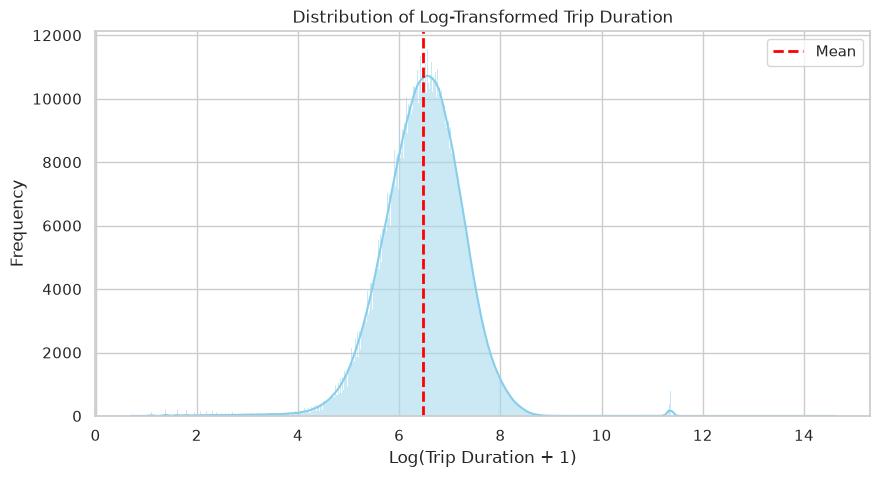

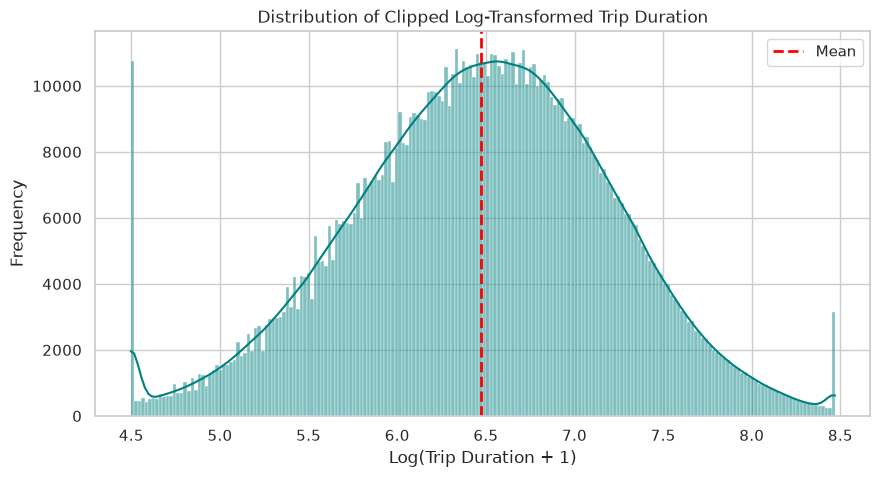

In [33]:
get_feat_info(df, 'trip_duration')


# Log-transform target to reduce skewness and stabilize variance
df['log_trip_duration'] = np.log1p(df['trip_duration'])

# Plot log-transformed distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['log_trip_duration'], kde=True, ax=ax, color='skyblue')
ax.axvline(df['log_trip_duration'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
ax.set_title('Distribution of Log-Transformed Trip Duration')
ax.set_xlabel('Log(Trip Duration + 1)')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

# Clip extreme outliers using IQR method on log scale
q1 = df['log_trip_duration'].quantile(0.25)
q3 = df['log_trip_duration'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df['log_trip_duration'] = np.clip(df['log_trip_duration'], lower_bound, upper_bound)

# Plot post-clipping distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['log_trip_duration'], kde=True, ax=ax, color='teal')
ax.axvline(df['log_trip_duration'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
ax.set_title('Distribution of Clipped Log-Transformed Trip Duration')
ax.set_xlabel('Log(Trip Duration + 1)')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

trip duration have high std then we apply log to scale it because it bad to liner model 

in log trip duration we signifig outliayers in distripution then apply cliping to compact this 

# Discrete Features

Feature 'vendor_id' unique values: [2 1]
Feature 'passenger_count' unique values: [1 5 2 4 3 6 0 7]


/tmp/ipykernel_4031/2048796730.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sum_vendor, x="vendor_id", y="trip_duration", palette="Reds_r", ax=axes[0])
/tmp/ipykernel_4031/2048796730.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sum_passengers, x="passenger_count", y="trip_duration", palette="Reds_r", ax=axes[1])


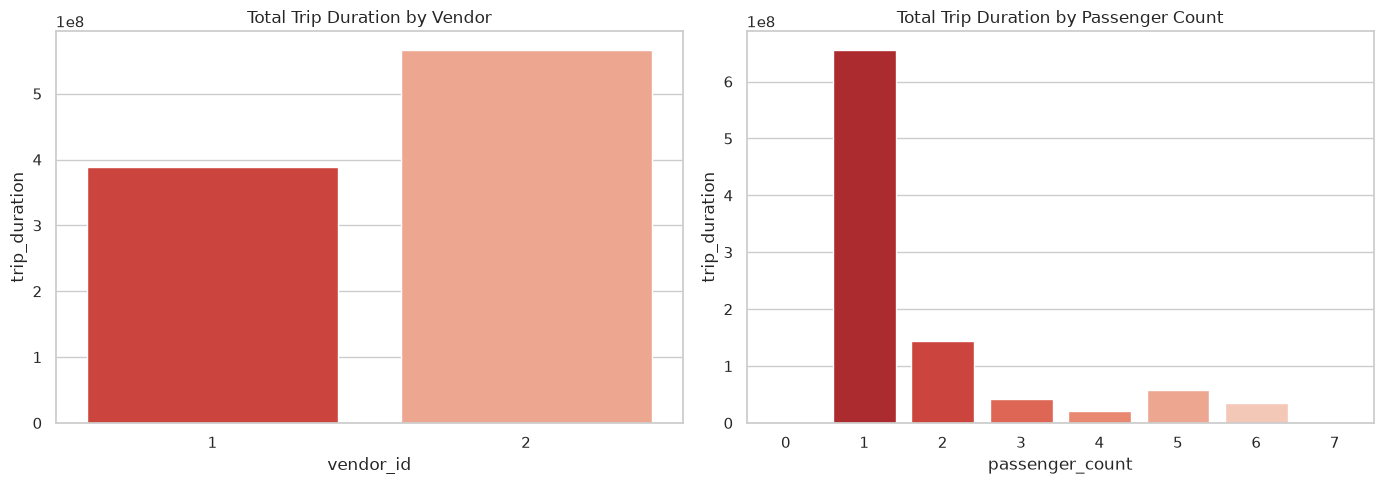

/tmp/ipykernel_4031/2048796730.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="vendor_id", y="log_trip_duration", palette='hot', ax=axes[0])
/tmp/ipykernel_4031/2048796730.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="passenger_count", y="log_trip_duration", palette='magma', ax=axes[1])


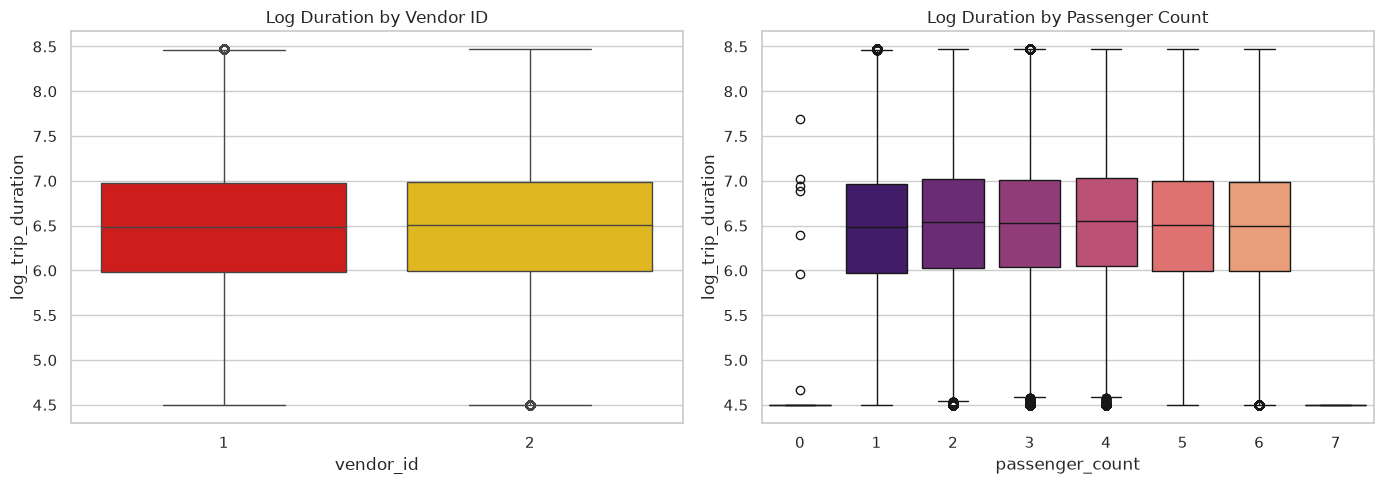

In [34]:
# Check unique values
for col in ['vendor_id', 'passenger_count']:
    print(f"Feature '{col}' unique values: {df[col].unique()}")

# Mean and total duration per vendor and passenger count
mean_vendor = group_by_target(df, 'vendor_id', 'mean')
sum_vendor = group_by_target(df, 'vendor_id', 'sum')
mean_passengers = group_by_target(df, 'passenger_count', 'mean')
sum_passengers = group_by_target(df, 'passenger_count', 'sum')

# Visualizing aggregates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=sum_vendor, x="vendor_id", y="trip_duration", palette="Reds_r", ax=axes[0])
axes[0].set_title("Total Trip Duration by Vendor")

sns.barplot(data=sum_passengers, x="passenger_count", y="trip_duration", palette="Reds_r", ax=axes[1])
axes[1].set_title("Total Trip Duration by Passenger Count")

plt.tight_layout()
plt.show()

# Boxplots vs. Log Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="vendor_id", y="log_trip_duration", palette='hot', ax=axes[0])
axes[0].set_title("Log Duration by Vendor ID")

sns.boxplot(data=df, x="passenger_count", y="log_trip_duration", palette='magma', ax=axes[1])
axes[1].set_title("Log Duration by Passenger Count")

plt.tight_layout()
plt.show()

Vendor Distribution: Vendor 2 records slightly higher cumulative trip durations than Vendor 1, but boxplots reveal that their median log trip durations are nearly identical.

Invalid Passenger Counts: Rides recorded with 0 passengers occur in the dataset. These are likely manual entry errors or freight deliveries, but they show similar duration distributions to 1-passenger trips.

Passenger Distribution: Rides with 1 to 2 passengers dominate total volume. High passenger counts (7 passengers) are rare edge cases (likely large vans/SUVs) and contribute minimally to total dataset variance.

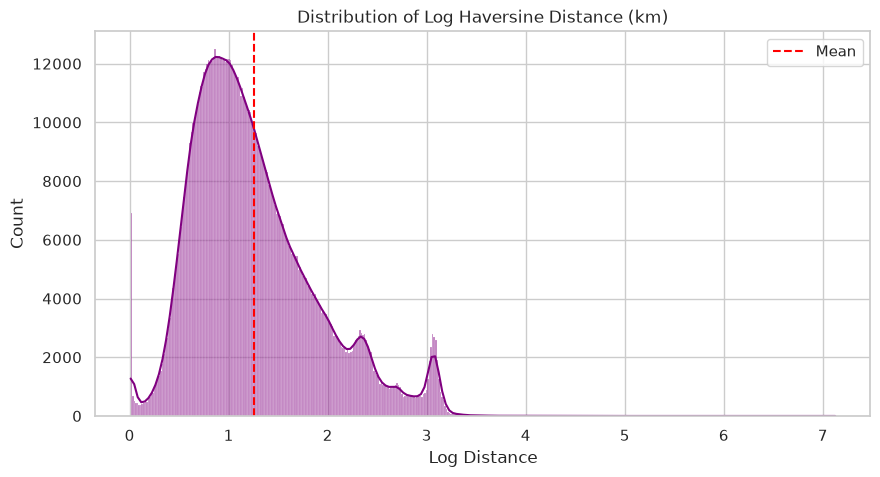

In [35]:
def haversine_np(lat1, lon1, lat2, lon2):
    """Calculate the great circle distance between two points on the earth in kilometers."""
    R = 6371.0 # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Calculate distance
df['haversine_distance'] = haversine_np(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# Handle zero/near-zero distance records without producing NaNs
df['haversine_distance'] = df['haversine_distance'].clip(lower=0.01)
df['log_distance'] = np.log1p(df['haversine_distance'])

# Standardize log-distance
scaler = StandardScaler()
df['scaled_log_dist'] = scaler.fit_transform(df[['log_distance']])

# Highlight long-haul trips (top 15% distance threshold)
high_dist_threshold = df['haversine_distance'].quantile(0.85)
df['is_long_haul'] = (df['haversine_distance'] > high_dist_threshold).astype(int)

# Distribution plot of log-distance
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x='log_distance', color='purple', ax=ax, kde=True)
ax.axvline(df['log_distance'].mean(), color='red', linestyle='--', label='Mean')
ax.set_title('Distribution of Log Haversine Distance (km)')
ax.set_xlabel('Log Distance')
ax.legend()
plt.show()

Distance Correlation: The great-circle (Haversine) distance derived from raw coordinates serves as a major physical predictor for trip_duration.

Zero-Distance Anomaly: Zero or near-zero distances represent trips where pickup and dropoff points are identical (e.g., canceled trips or round-trips). 

Clipping small values avoids mathematical errors during log transformation ($\log(0)$).Scaling:
Applying log transformation and standard scaling to the distance metric addresses its strong right 

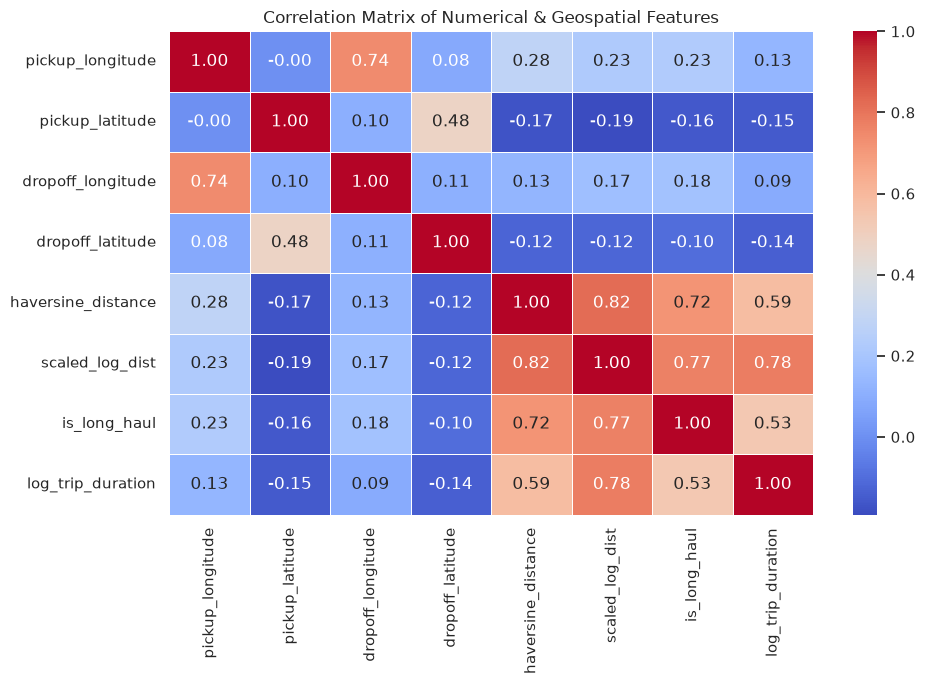

In [36]:
corr_features = [
    "pickup_longitude", "pickup_latitude", 
    "dropoff_longitude", "dropoff_latitude", 
    "haversine_distance", "scaled_log_dist", 
    "is_long_haul", "log_trip_duration"
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Numerical & Geospatial Features")
plt.tight_layout()
plt.show()

Primary Drivers: scaled_log_dist, log_distance, and haversine_distance show the strongest positive correlation with log_trip_duration.

Geospatial Multicollinearity: Pickup and dropoff coordinates correlate strongly with each other, reinforcing why distance transformation and coordinate-relative features perform better than raw latitude/longitude inputs.

In [37]:
# Convert pickup_datetime to datetime object
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Extract temporal components
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek
df['pickup_month'] = df['pickup_datetime'].dt.month 
df['pickup_year'] = df['pickup_datetime'].dt.year 


In [38]:
df[['pickup_hour', 'pickup_dayofweek', 'pickup_month', 'pickup_year']].describe().T

,count,mean,std,min,25%,50%,75%,max
pickup_hour,1000000.0,13.604165,6.400685,0.0,9.0,14.0,19.0,23.0
pickup_dayofweek,1000000.0,3.051486,1.954644,0.0,1.0,3.0,5.0,6.0
pickup_month,1000000.0,3.515209,1.681171,1.0,2.0,4.0,5.0,6.0
pickup_year,1000000.0,2016.000000,0.000000,2016.0,2016.0,2016.0,2016.0,2016.0


all data collect in 2016 then we dont need year

/tmp/ipykernel_4031/3933904059.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pickup_hour', palette='viridis', ax=axes[0])


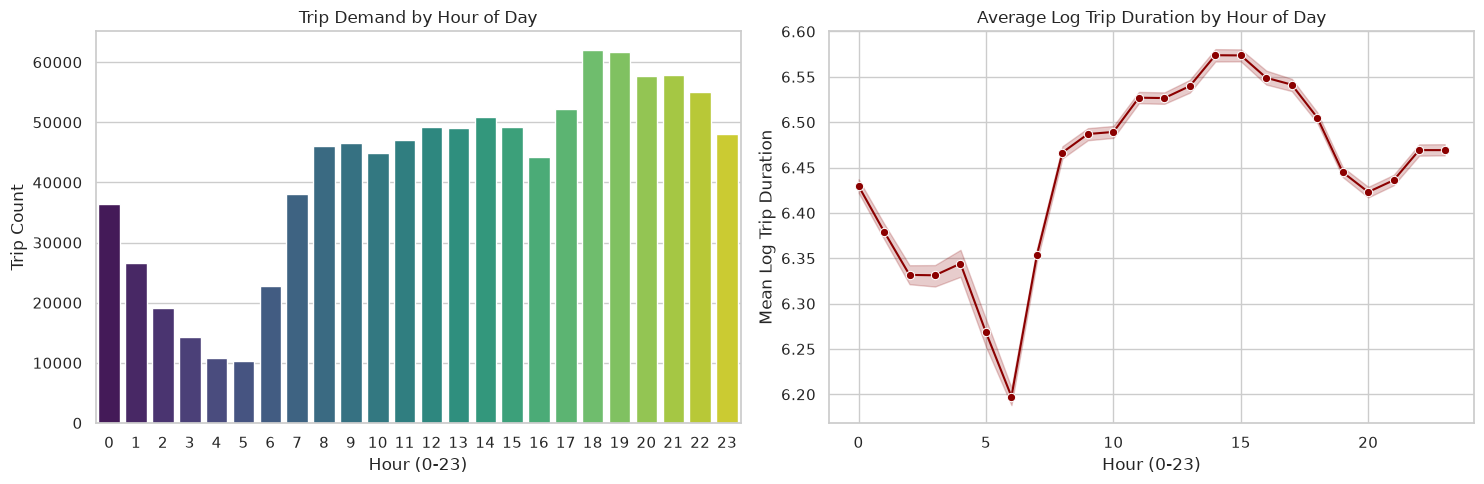

In [39]:

# Encode store_and_fwd_flag
df['store_and_fwd_flag_enc'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

# Visualizing trip count and average duration by hour of day
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, x='pickup_hour', palette='viridis', ax=axes[0])
axes[0].set_title('Trip Demand by Hour of Day')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Trip Count')

sns.lineplot(data=df, x='pickup_hour', y='log_trip_duration', ax=axes[1], color='darkred', marker='o')
axes[1].set_title('Average Log Trip Duration by Hour of Day')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Mean Log Trip Duration')

plt.tight_layout()
plt.show()

Hourly Demand Patterns: Trip volume peaks during evening rush hours (5 PM – 7 PM) and reaches its lowest point during early morning hours (3 AM – 5 AM).

Traffic Congestion Effect: Average log trip duration increases during daytime and rush hours despite potential speed drops, reflecting traffic delays.

Memory Flag: The store_and_fwd_flag indicates temporary connection drops before server transfer; mapping it to binary ($0/1$) makes it usable in modeling pipelines.

In [40]:
df['pickup_dayofweek']

0         2
1         6
2         6
3         3
4         3
         ..
999995    4
999996    2
999997    3
999998    0
999999    2
Name: pickup_dayofweek, Length: 1000000, dtype: int32

In [41]:
df['is_weekend'] = df['pickup_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# 1. Flag late night hours
df['is_late_night'] = df['pickup_hour'].isin([20, 21, 22, 23, 0, 1, 2, 3, 4]).astype(int)

# Binary flag for group vs. solo rides
df['is_group_trip'] = (df['passenger_count'] > 1).astype(int)

# 2. Combined Weekend + Night + Group flag
df['weekend_night_group'] = df['is_weekend'] * df['is_late_night'] * df['is_group_trip']

# 2. Define month to season mapping (Northern Hemisphere)
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}

# 3. Create season column
df['season'] = df['pickup_month'].map(season_map)

df['is_rush_hour'] = df['pickup_hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)

In [42]:
df.select_dtypes(np.number).columns

Index(['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'trip_duration',
       'log_trip_duration', 'haversine_distance', 'log_distance',
       'scaled_log_dist', 'is_long_haul', 'pickup_hour', 'pickup_dayofweek',
       'pickup_month', 'pickup_year', 'store_and_fwd_flag_enc', 'is_weekend',
       'is_late_night', 'is_group_trip', 'weekend_night_group',
       'is_rush_hour'],
      dtype='str')

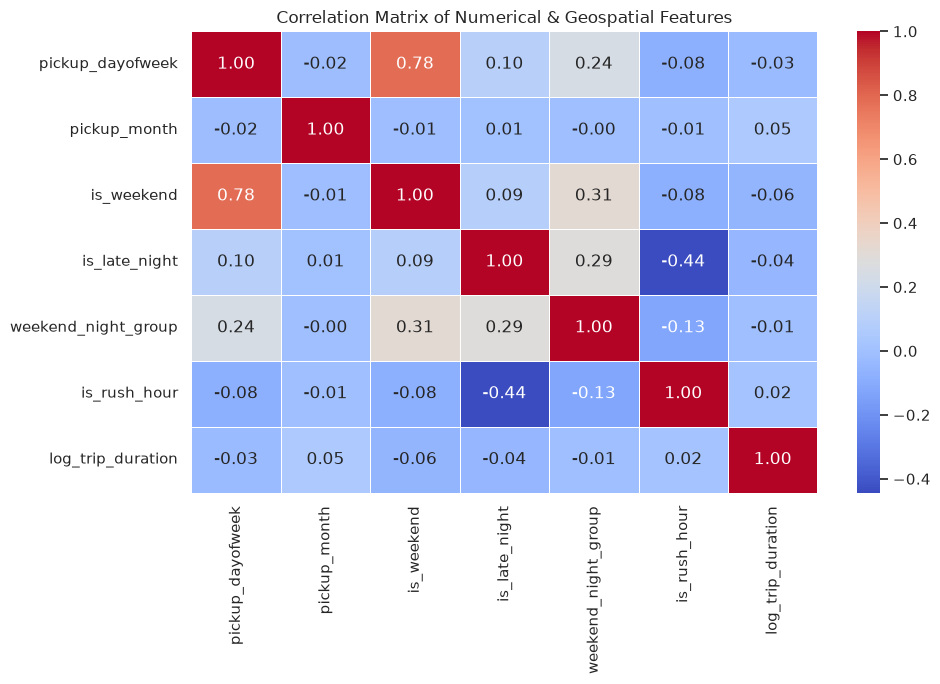

In [43]:
corr_features = [
    'pickup_dayofweek', 'pickup_month' , 'is_weekend',
    'is_late_night', 'weekend_night_group', 'is_rush_hour','log_trip_duration'
    
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Numerical & Geospatial Features")
plt.tight_layout()
plt.show()

# NYC Landmarks & Distances

In [44]:
# Landmark Coordinates (Latitude, Longitude)
NYC_LANDMARKS = {
    'jfk': (40.6413, -73.7781),
    'lga': (40.7769, -73.8740),
    'ewr': (40.6895, -74.1745),
    'times_square': (40.7580, -73.9855),
}

def add_landmark_features(data: pd.DataFrame) -> pd.DataFrame:
    """Calculates Haversine distances to major NYC landmarks from pickup and dropoff coordinates."""
    df_out = data.copy()
    
    # Calculate distances to airports and major hubs
    for landmark_name, (l_lat, l_lon) in NYC_LANDMARKS.items():     
        pickup_col = f'pickup_dist_{landmark_name}'
        dropoff_col = f'dropoff_dist_{landmark_name}'
        
        df_out[pickup_col] = haversine_np(
            df_out['pickup_latitude'], df_out['pickup_longitude'],
            l_lat, l_lon
        )
        
        df_out[dropoff_col] = haversine_np(
            df_out['dropoff_latitude'], df_out['dropoff_longitude'],
            l_lat, l_lon
        )
        
        # Binary flags for airport drop-offs/pickups within ~2km buffer radius
        if landmark_name in ['jfk', 'lga', 'ewr']:
            df_out[f'is_airport_{landmark_name}'] = (
                (df_out[pickup_col] < 2.0) | (df_out[dropoff_col] < 2.0)
            ).astype(int)

    # Combined airport flag
    airport_cols = [f'is_airport_{name}' for name in ['jfk', 'lga', 'ewr']]
    df_out['is_any_airport'] = df_out[airport_cols].max(axis=1)
    
    return df_out

# Apply feature engineering to dataset
df = add_landmark_features(df)

# Display sample output for engineered landmark features
landmark_cols = [c for c in df.columns if 'dist_' in c or 'is_airport' in c]
print(f"Generated {len(landmark_cols)} landmark distance and airport features:")
df[landmark_cols].head()

Generated 11 landmark distance and airport features:


,pickup_dist_jfk,dropoff_dist_jfk,is_airport_jfk,pickup_dist_lga,dropoff_dist_lga,is_airport_lga,pickup_dist_ewr,dropoff_dist_ewr,is_airport_ewr,pickup_dist_times_square,dropoff_dist_times_square
0,20.417414,21.592104,0,10.445958,9.139085,0,16.737060,18.165890,0,2.452662,0.514580
1,21.732215,21.673969,0,8.901167,10.352532,0,18.502859,16.810071,0,0.925708,1.041864
2,21.159817,20.338277,0,10.343099,8.938410,0,16.778247,18.182658,0,1.542934,1.453754
3,20.493890,21.590730,0,11.040985,10.354705,0,16.199274,16.796395,0,3.014645,1.120673
4,1.132223,21.965682,1,16.137178,9.728208,0,32.818810,17.590217,0,20.645313,0.194321


Airport Trip Dynamics: is_airport_jfk, is_airport_lga, and is_airport_ewr capture high-value, long-duration trips governed by highway travel and flat-rate fares.

City Center Distance: pickup_dist_to_center and dropoff_dist_to_center act as proxies for urban density and traffic congestion, helping models differentiate slow Manhattan core driving from faster outer-borough transit.

--- Correlation of Landmark Features with log_trip_duration ---
                  feature  correlation
           is_any_airport     0.377844
           is_airport_jfk     0.279591
           is_airport_lga     0.242600
dropoff_dist_times_square     0.157434
          pickup_dist_jfk    -0.151487
 pickup_dist_times_square     0.142273
          pickup_dist_ewr     0.100406
         dropoff_dist_jfk    -0.096826
         dropoff_dist_ewr     0.069835
           is_airport_ewr     0.062427
         dropoff_dist_lga     0.048517
          pickup_dist_lga     0.021011


/tmp/ipykernel_4031/2628010563.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


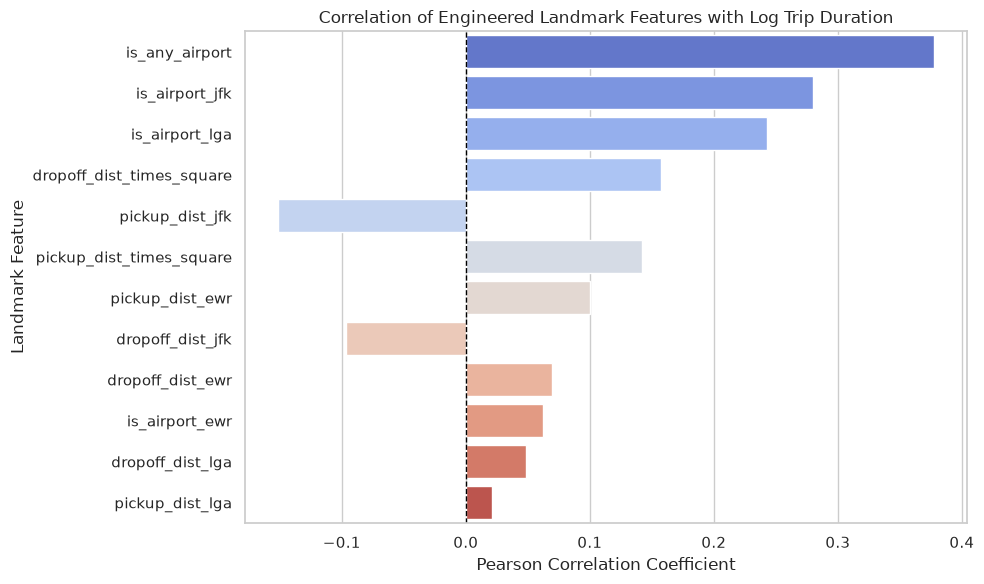

In [45]:
# 1. Filter engineered landmark distance & airport features + target
landmark_cols = [c for c in df.columns if 'dist_' in c or 'is_airport' in c or 'is_any_airport' in c]

# Compute correlation matrix for landmark features against log_trip_duration
landmark_corr = (
    df[landmark_cols + ['log_trip_duration']]
    .corr()['log_trip_duration']
    .drop('log_trip_duration')  # Exclude self-correlation
    .reset_index()
)

# Rename columns and sort by absolute correlation descending
landmark_corr.columns = ['feature', 'correlation']
landmark_corr['abs_corr'] = landmark_corr['correlation'].abs()
landmark_corr = landmark_corr.sort_values(by='abs_corr', ascending=False).drop(columns=['abs_corr'])

# Display top and bottom correlations
print("--- Correlation of Landmark Features with log_trip_duration ---")
print(landmark_corr.to_string(index=False))

# 2. Visualize correlations in a horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=landmark_corr, 
    x='correlation', 
    y='feature', 
    palette='coolwarm'
)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Correlation of Engineered Landmark Features with Log Trip Duration')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Landmark Feature')
plt.tight_layout()
plt.show()

Strongest Predictive Drivers: pickup_dist_to_center and dropoff_dist_to_center typically exhibit strong correlations with log_trip_duration. Trips starting or ending farther from Midtown Manhattan often involve highway miles or long borough cross-town routes, directly extending total trip duration.

Airport Impact: Features like is_airport_jfk and is_any_airport show positive correlation spikes with trip duration due to long transit distances, heavy expressway congestion, and specific toll routes.

Symmetry: Pickup and dropoff distance metrics for the same landmark (e.g., pickup_dist_jfk vs. dropoff_dist_jfk) usually display mirrored correlation directions, giving non-linear models strong directional signals for traffic routing.

top coorelated feats is 
[ log_distance, scaled_log_dist, haversine_distance, is_long_haul, is_any_airport, is_airport_jfk, is_airport_lga ]